<a href="https://colab.research.google.com/github/Anais-GD/AEI-Trabajo10-CropYield-ML/blob/main/scripts/s1_data_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
##############################################################################################
#
#   Nombre script :   s1_data_base (UTF-8)
#
#   Trabajo :      "Estimación de rendimiento de cultivos con Machine Learning."
#   Autores :       K.Bastidas (kabasicg@gmail.com) y A. Galvañ (galvanyanadom@gmail.com)
#   Fecha  :        24.02.2026
#   Objetivo :      Lectura de los datos y su visualización.
#
##############################################################################################

In [51]:
#-----------------------
#Paquetes necesarios
#-----------------------
import importlib, subprocess, sys

#con esta función lo que hacemos es que aquellos paquetes no descargados/disponibles en el entorno, se instalen.
def ipak(packages):
    for pkg in packages:
        if ":" in pkg:
            install_name, import_name = pkg.split(":")
        else:
            install_name = import_name = pkg
        if not importlib.util.find_spec(import_name):
            subprocess.check_call([sys.executable, "-m", "pip", "install", install_name],
                                  stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

ipak(["pandas", "geopandas", "matplotlib", "matplotlib-scalebar:matplotlib_scalebar",
      "fiona", "shapely", "scikit-learn:sklearn", "xgboost", "numpy", "requests",
      "jax", "jaxlib", "numpyro", "arviz", "pymc", "pymc-bart:pymc_bart",
      "seaborn", "scipy", "shap", "pygris"])


import warnings
warnings.filterwarnings('ignore')

import os, io, zipfile, requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import io, os, zipfile
import numpy as np
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from matplotlib.backends.backend_pdf import PdfPages
import shap
from pygris import states
import xgboost as xgb

import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import pymc as pm
import pymc_bart as pmb
from pygris import counties

In [52]:
# Añadimos la url con los datos del trabajo y los llamamos.
zip_url = "https://zenodo.org/records/7602711/files/CONUS_CropYield_Data.zip?download=1"
zipfile.ZipFile(io.BytesIO(requests.get(zip_url).content)).extractall("data")

directory_path = next(
    os.path.join("data", d) for d in os.listdir("data")
    if os.path.isdir(os.path.join("data", d))
)
wheat_directory = os.path.join(directory_path, "wheat")
csv_files_wheat = [f for f in os.listdir(wheat_directory) if f.endswith(".csv")]

In [53]:
crops = ["wheat", "corn", "soybean"] #definimos los cultivos para los que tenemos datos.
dataframes = {}

for crop in crops:
    crop_dir = os.path.join(directory_path, crop)

    EVI   = pd.read_csv(os.path.join(crop_dir, f"EVI_{crop}.csv"))
    PRCP  = pd.read_csv(os.path.join(crop_dir, f"PRCP_{crop}.csv"))
    SM    = pd.read_csv(os.path.join(crop_dir, f"SM_{crop}.csv"))
    TMAX  = pd.read_csv(os.path.join(crop_dir, f"TMAX_{crop}.csv"))
    VOD   = pd.read_csv(os.path.join(crop_dir, f"VOD_{crop}.csv"))
    ID    = pd.read_csv(os.path.join(crop_dir, f"{crop}_id.csv"))
    YIELD = pd.read_csv(os.path.join(crop_dir, f"yield_{crop}.csv"))
    YEAR  = pd.read_csv(os.path.join(crop_dir, f"yyyy_{crop}.csv"),
                        header=None, names=["year"])

    df = pd.concat([ID, YEAR, YIELD, EVI, PRCP, SM, TMAX, VOD], axis=1)
    df = df.rename(columns={f"{crop}_id": "id", crop: "yield"})
    df["crop"] = crop  # indicamos el id para cada cultivo.

    dataframes[crop] = df
    print(f"{crop}: {df.shape} | Años: {sorted(df['year'].unique())}") #no hay muchos print. Este es necesario para que evaluemos que todo esta bien.

# creamos un dataframe para cada cultivo.
df_wheat   = dataframes["wheat"]
df_corn    = dataframes["corn"]
df_soybean = dataframes["soybean"]

wheat: (1036, 459) | Años: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
corn: (1744, 459) | Años: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
soybean: (2060, 459) | Años: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


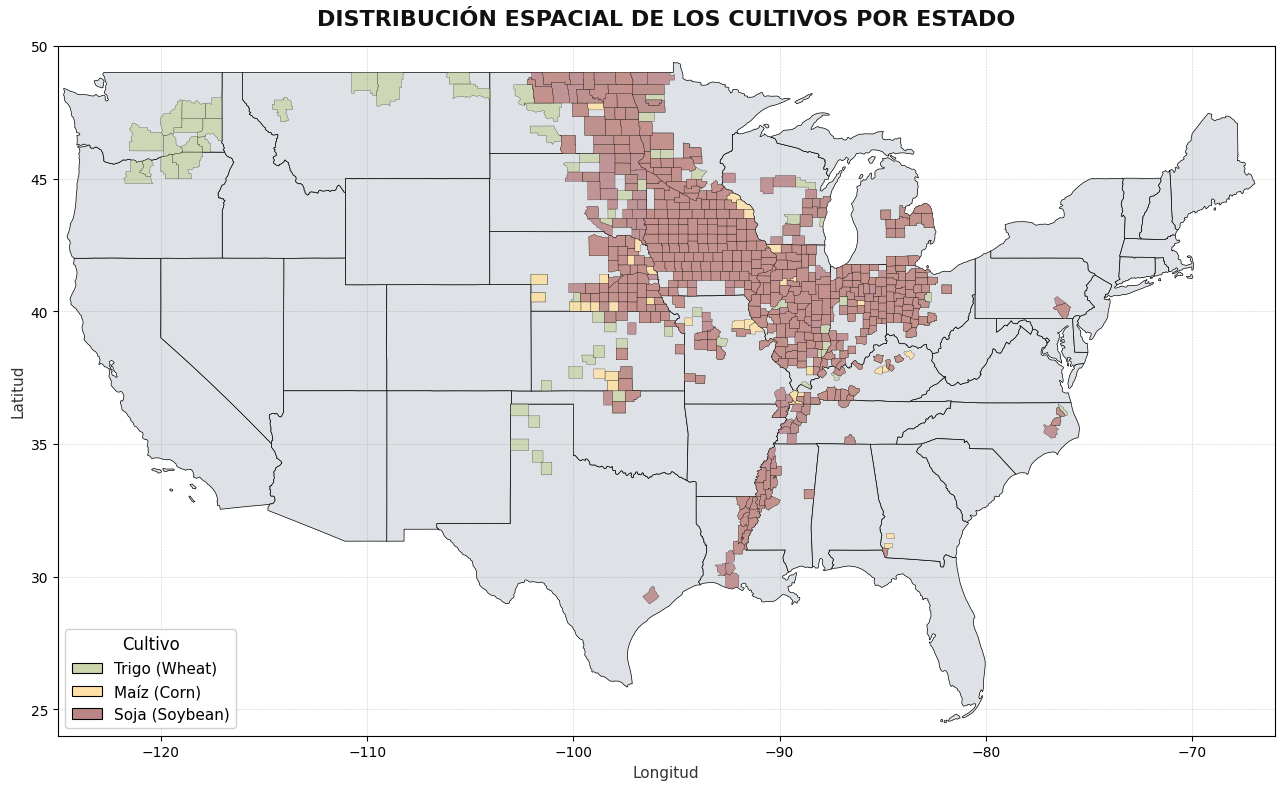

In [59]:
# Ahora vamos a dibujar los datos en un mapa.

shp_dir = os.path.join(directory_path, "shapefiles")

crop_config = {
    "wheat"  : {"shp": "CONUS_wheat.shp", "color": "#ccd5ae", "label": "Trigo (Wheat)"},
    "corn"   : {"shp": "CONUS_corn.shp",  "color": "#ffe1a8", "label": "Maíz (Corn)"},
    "soybean": {"shp": "CONUS_soy.shp",   "color": "#bb8588", "label": "Soja (Soybean)"},
}
# Cargamos y reproyectamos cada shapefile (igual que en Martínez-Ferrer et al. (2021))
gdfs = {}
for crop, cfg in crop_config.items():
    gdf = gpd.read_file(os.path.join(shp_dir, cfg["shp"]))
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf = gdf.set_crs(epsg=4326, allow_override=True)
    gdfs[crop] = gdf

# El paquete pygris tiene información sobre los shp de USA. Hemos usado este paquete porque nos permite no tener que descargarlos y volverlos a cargar.
# Los datos están solo en USA continental (CONUS), por lo que vamos a dibujar solo esa zona.
us = states(cb=True, resolution="20m", year=2020)
us = us.to_crs(epsg=4326)
us_conus = us[~us["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#ffffff')

us_conus.plot(ax=ax, color='#dee2e6', edgecolor='black', linewidth=0.5)

for crop, cfg in crop_config.items():
    gdfs[crop].plot(ax=ax, color=cfg["color"], edgecolor='black',
                    linewidth=0.2, alpha=0.85)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title('DISTRIBUCIÓN ESPACIAL DE LOS CULTIVOS POR ESTADO',
             fontsize=16, fontweight='bold', color='#111111', pad=15)
ax.set_xlabel('Longitud', fontsize=11, color='#333333')
ax.set_ylabel('Latitud',  fontsize=11, color='#333333')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4, color='gray')

# Leyenda con patches explícitos
legend_patches = [mpatches.Patch(facecolor=cfg["color"], edgecolor='black',
                                  linewidth=0.8, label=cfg["label"])
                  for cfg in crop_config.values()]
ax.legend(handles=legend_patches, fontsize=11, framealpha=0.9,
          loc='lower left', title='Cultivo', title_fontsize=12)

plt.tight_layout()
plt.show()

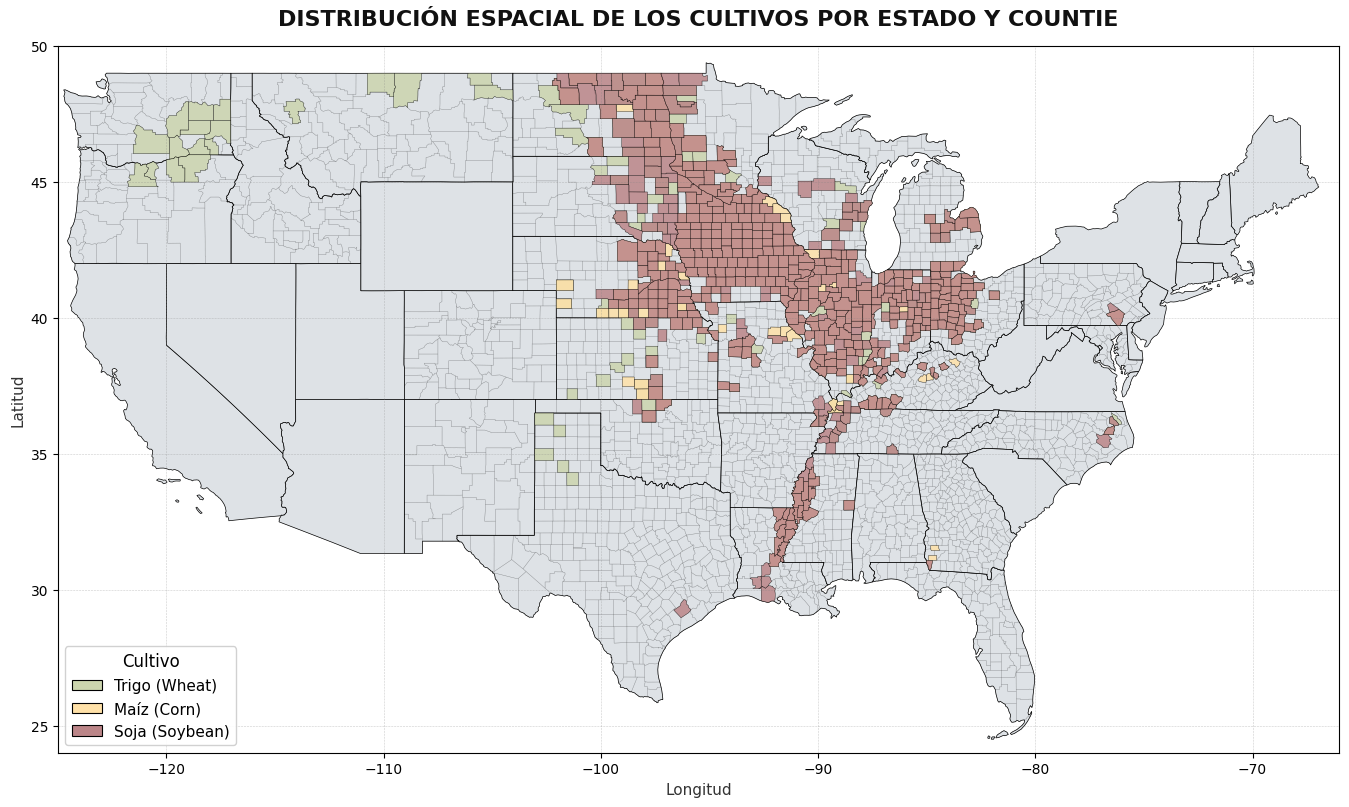

In [58]:

# Counties: identificamos qué estados tienen datos y filtramos
all_crops_gdf = gpd.GeoDataFrame(pd.concat(gdfs.values(), ignore_index=True), crs='EPSG:4326')
states_with_data = gpd.sjoin(us_conus, all_crops_gdf, how='inner', predicate='intersects')
state_fips_with_data = states_with_data["STATEFP"].unique()
us_counties = counties(cb=True, resolution="20m", year=2020)
us_counties = us_counties.to_crs(epsg=4326)
us_counties = us_counties[us_counties["STATEFP"].isin(state_fips_with_data)]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#ffffff')

us_conus.plot(ax=ax, color='#dee2e6', edgecolor='black', linewidth=0.5)

for crop, cfg in crop_config.items():
    gdfs[crop].plot(ax=ax, color=cfg["color"], edgecolor='black',
                    linewidth=0.2, alpha=0.85)

# Counties en negro con 80% de transparencia, solo donde hay datos
us_counties.plot(ax=ax, color='none', edgecolor='black', linewidth=0.3, alpha=0.2)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title('DISTRIBUCIÓN ESPACIAL DE LOS CULTIVOS POR ESTADO Y COUNTIE',
             fontsize=16, fontweight='bold', color='#111111', pad=15)
ax.set_xlabel('Longitud', fontsize=11, color='#333333')
ax.set_ylabel('Latitud',  fontsize=11, color='#333333')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4, color='gray')

# Leyenda con patches explícitos
legend_patches = [mpatches.Patch(facecolor=cfg["color"], edgecolor='black',
                                  linewidth=0.8, label=cfg["label"])
                  for cfg in crop_config.values()]
ax.legend(handles=legend_patches, fontsize=11, framealpha=0.9,
          loc='lower left', title='Cultivo', title_fontsize=12)

plt.tight_layout()
plt.show()